# PINNs — Teoría en Código
### Proyecto: Simulación Acelerada de Speckle Óptico
**Roberto Hernández Estrada** | UJAT — Maestría en Ciencias de la Computación

---
**Objetivo de este notebook:** Entender y validar los bloques fundamentales de una PINN
resolviendo la ecuación de Helmholtz en 1D antes de pasar al caso 2D de la tesis.

**Problema a resolver:**
$$\frac{d^2E}{dx^2} + k^2 E = 0, \quad x \in [0,1]$$
$$E(0) = 1, \quad E(1) = \cos(k)$$
**Solución analítica conocida:** $E(x) = \cos(kx)$

## 0. Imports y configuración del entorno

In [1]:
import sys
import os
sys.path.append('..')   # sube de notebooks/ a la raíz del proyecto

import torch
import time
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Importar desde src/ ───────────────────────────────────────────────────────
from src.models import PINN_1D_SIREN
from src.losses import pinn_loss_1d
from src.utils  import get_figures_dir, save_model

# ── Semilla global — SIEMPRE al inicio para reproducibilidad ──────────────────
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Dispositivo — forzado a CPU para garantizar determinismo completo ─────────
device = torch.device('cpu')
print(f'Dispositivo     : {device}')
print(f'Semilla fijada  : {SEED}')
print('\n Entorno listo y reproducible.')


Dispositivo     : cpu
Semilla fijada  : 42

 Entorno listo y reproducible.


---
## 1. Arquitectura de la red — PINN 1D

Red MLP con activación `SIREN (Sinusoidal Representation Networks)` — infinitamente diferenciable, necesaria para calcular
derivadas de segundo orden con autograd.

```
Entrada (x) → [64] → Sine (ω₀) → [64] → Sine (ω₀) → [64] → Sine (ω₀) → [64] → Sine (ω₀) → [64] → Sine (ω₀) → Salida E(x)
```

###  ¿Por qué esta arquitectura?

En una PINN, la red neuronal **aproxima la solución** de una ecuación diferencial.
En tu caso: la red aprenderá a predecir el campo eléctrico `E(x, y)` dados puntos del dominio.

La arquitectura base es un **MLP (Perceptrón Multicapa)**:
```
Entrada (x) → [64] → SINE → [64] → SINE → [64] → SINE → [64] → SINE → Salida E(x)
```

> **¿Por qué `SINE` y no `ReLU`?**  
> Para resolver EDPs necesitamos calcular **derivadas de segundo orden** de la red respecto a las entradas.  
> - `SINE` es suave e **infinitamente diferenciable** → derivadas bien definidas en todo el dominio  
> - `ReLU` tiene segunda derivada = 0 en casi todo el dominio → **el residuo de Helmholtz siempre parecería cero** aunque la red no haya aprendido nada  

> **¿Por qué inicialización de Sitzmann et al. (2020)?**
> SIREN requiere una inicialización especial: la primera capa usa U(-1/n_in, 1/n_in)
> y las capas ocultas usan U(-√6/n_in, √6/n_in) / ω₀. Esto garantiza que
> las activaciones sinusoidales cubran el rango [-1, 1] desde el inicio,
> evitando la explosión de gradientes que ocurre con ω₀=30 e inicialización estándar.

In [2]:
# Sine y PINN_1D_SIREN importados desde src/models.py
# Ver src/models.py para la implementacion completa (Sitzmann et al., 2020)

# ── Vista previa de la arquitectura ───────────────────────────────────────────
torch.manual_seed(SEED)
_preview = PINN_1D_SIREN(hidden_dim=64, num_layers=5, omega_0=1.0)
print('Arquitectura SIREN PINN 1D:')
print(_preview)
print(f'\nTotal de parametros: {sum(p.numel() for p in _preview.parameters()):,}')
del _preview


Arquitectura SIREN PINN 1D:
PINN_1D_SIREN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Sine()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Sine()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Sine()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Sine()
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): Sine()
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total de parametros: 16,833


---
## 2. Funciones auxiliares — Derivadas y Residuo de Helmholtz

Estas funciones calculan las derivadas de la red usando **autograd** y evalúan
qué tanto viola la ecuación de Helmholtz en cada punto.

### ¿Qué es la diferenciación automática (Autograd)?

Este es el **corazón de las PINNs**. Para evaluar si la red cumple la ecuación de Helmholtz:

$$\nabla^2 E + k^2 E = 0 \quad \Rightarrow \quad \frac{\partial^2 E}{\partial x^2} + \frac{\partial^2 E}{\partial y^2} + k^2 E = 0$$

necesitamos calcular **derivadas de la salida de la red respecto a sus entradas**.

PyTorch hace esto automáticamente construyendo un **grafo computacional** — registra cada operación matemática y al pedir la derivada recorre ese grafo al revés aplicando la regla de la cadena:

```
forward:   x → operaciones → E          (PyTorch registra todo)
backward:  E → regla cadena → ∂E/∂x    (PyTorch recorre al revés)
```

> **Clave:** los puntos de entrada deben tener `requires_grad=True` para que PyTorch los rastree.  
> **`create_graph=True`** permite calcular derivadas de segundo orden (necesario para ∂²E/∂x²).  
> **`retain_graph=True`** evita que PyTorch borre el grafo entre cálculos de derivadas.

In [3]:
# helmholtz_residual_1d y pinn_loss_1d importados desde src/losses.py
# Ver src/losses.py para la implementacion completa

print(' Funciones auxiliares cargadas desde src/losses.py')
print('   helmholtz_residual_1d() — calcula R = E\'\' + k²E')
print('   pinn_loss_1d()          — calcula L_total = L_datos + λ·L_física')


 Funciones auxiliares cargadas desde src/losses.py
   helmholtz_residual_1d() — calcula R = E'' + k²E
   pinn_loss_1d()          — calcula L_total = L_datos + λ·L_física


---
## 3. Configuración del experimento

Todos los hiperparámetros en un solo lugar — fácil de modificar y documentar.

### La Ecuación de Helmholtz y el concepto de residuo

La ecuación que gobierna tu tesis es:

$$\nabla^2 E + k^2 E = 0$$

Donde `k = 2π/λ` es el número de onda relacionado con la longitud de onda del láser.

El **residuo** es qué tanto viola la red esta ecuación en cada punto:

$$R(x) = \frac{d^2E}{dx^2} + k^2 E \quad \text{(debe ser } \approx 0 \text{ en todo el dominio)}$$

| Situación | Residuo |
|---|---|
| Red perfecta | R = 0 en todo el dominio  |
| Red sin entrenar | R ≠ 0, valores grandes |
| Durante entrenamiento | R → 0 gradualmente |

> La PINN **no necesita malla** — evalúa el residuo en puntos libres del dominio.  
> Esto es la ventaja *mesh-free* que argumentas en tu protocolo de tesis.

In [4]:
# ── Hiperparámetros ────────────────────────────────────────────────────────────
CONFIG = {
    # ── Láser simulado (documentación - no entra en cálculos de la PINN) ──────
    'lambda_laser' : 638e-9,     # diodo rojo λ = 638 nm (computacional)
    'L'            : 1,          # dominio = 1 longitud de onda (Fase 1 validación)

    # ── Física adimensional ────────────────────────────────────────────────────
    'k'           : 2 * np.pi,   # k̃ adimensional - siempre 2π por definición
                                  # k_real = 2π/λ = 9.85×10⁶ m⁻¹ (diodo rojo 638nm)
                                  # al adimensionalizar: k̃ = k_real × λ = 2π siempre

    # ── Puntos ─────────────────────────────────────────────────────────────────
    'N_colloc'    : 2000,        # puntos de colocación interiores
    'N_boundary'  : 5,           # puntos conocidos (x=0, 0.25, 0.5, 0.75, 1.0)

    # ── Arquitectura ───────────────────────────────────────────────────────────
    'hidden_dim'  : 64,          # neuronas por capa oculta
    'num_layers'  : 5,           # capas ocultas
    'omega_0'      : 1.0,        # frecuencia de activación sinusoidal (SIREN)


    # ── Entrenamiento ──────────────────────────────────────────────────────────
    'n_epochs'    : 15000,       # épocas máximas (early stopping puede parar antes)
    'lr'          : 1e-3,        # learning rate de Adam
    'lambda_phys' : 1.0,        # peso de la pérdida física
                                  # 1.0 = datos y física tienen el mismo peso

    # ── Reproducibilidad ───────────────────────────────────────────────────────
    'seed'        : SEED,          # semilla global para reproducibilidad

    # ── Meta de la tesis ───────────────────────────────────────────────────────
    'l2_threshold': 0.05,        # < 5% según hipótesis del protocolo
}

print('Configuración del experimento:')
print('-' * 40)
for key, val in CONFIG.items():
    print(f'  {key:<15} : {val}')
print('-' * 40)
print(f'  Solución esperada: E(x) = cos({CONFIG["k"]:.4f} · x)')
print()

# ── Equivalencia física del láser simulado ─────────────────────────────────────
lam = CONFIG['lambda_laser']
L   = CONFIG['L']
print('Láser simulado:')
print(f'  Tipo                : Diodo rojo (computacional)')
print(f'  lambda_laser        : {lam * 1e9:.0f} nm')
print(f'  k adimensional      : 2π = {CONFIG["k"]:.4f}')
print(f'  k real equivalente  : {2 * np.pi / lam:.3e} m⁻¹')
print(f'  Dominio simulado    : {L} longitud de onda')
print(f'  Equivale físicamente: {L * lam * 1e6:.4f} μm')

Configuración del experimento:
----------------------------------------
  lambda_laser    : 6.38e-07
  L               : 1
  k               : 6.283185307179586
  N_colloc        : 2000
  N_boundary      : 5
  hidden_dim      : 64
  num_layers      : 5
  omega_0         : 1.0
  n_epochs        : 15000
  lr              : 0.001
  lambda_phys     : 1.0
  seed            : 42
  l2_threshold    : 0.05
----------------------------------------
  Solución esperada: E(x) = cos(6.2832 · x)

Láser simulado:
  Tipo                : Diodo rojo (computacional)
  lambda_laser        : 638 nm
  k adimensional      : 2π = 6.2832
  k real equivalente  : 9.848e+06 m⁻¹
  Dominio simulado    : 1 longitud de onda
  Equivale físicamente: 0.6380 μm


---
## 4. Preparar datos de entrenamiento

### La Función de Pérdida PINN

La función de pérdida total combina dos tipos de error:

$$\mathcal{L}_{total} = \mathcal{L}_{datos} + \lambda \cdot \mathcal{L}_{física}$$

| Término | Qué mide | Dónde se evalúa |
|---|---|---|
| $\mathcal{L}_{datos}$ | Error en puntos conocidos | Condiciones de frontera |
| $\mathcal{L}_{física}$ | Residuo de Helmholtz | Puntos de colocación interiores |

> **¿Qué es λ (lambda_phys)?**  
> Controla el balance entre ambos términos.  
> - `λ = 1.0` → datos y física tienen igual peso  
> - `λ = 0.01` → datos importan 100x más que la física (necesario cuando las condiciones de frontera son simétricas)  

> **Lección aprendida en este notebook:**  
> Con condiciones simétricas (E(0) = E(1) = 1), usar `λ` grande hace que la red ignore los datos  
> y colapse a u ≈ 1 constante. Reducir `λ = 0.01` y agregar puntos intermedios conocidos resuelve el problema.

In [5]:
k = CONFIG['k']

# ── Puntos de colocación ──────────────────────────────────────────────────────
x_colloc = torch.linspace(0, 1, CONFIG['N_colloc']).reshape(-1, 1).to(device)

# ── Condiciones de frontera EXTENDIDAS ────────────────────────────────────────
# Agregamos puntos intermedios donde conocemos la solución exacta
# cos(2πx) en puntos clave: 0, 0.25, 0.5, 0.75, 1.0
x_bc_vals = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
E_bc_vals = np.cos(k * x_bc_vals)

print('Condiciones de frontera extendidas:')
for x_val, E_val in zip(x_bc_vals, E_bc_vals):
    print(f'  E({x_val}) = {E_val:.4f}')

x_bc = torch.tensor(x_bc_vals.reshape(-1, 1), dtype=torch.float32).to(device)
E_bc = torch.tensor(E_bc_vals.reshape(-1, 1), dtype=torch.float32).to(device)

Condiciones de frontera extendidas:
  E(0.0) = 1.0000
  E(0.25) = 0.0000
  E(0.5) = -1.0000
  E(0.75) = -0.0000
  E(1.0) = 1.0000


---
## 5. Entrenamiento

### El loop de entrenamiento — estrategia híbrida Adam + L-BFGS

El entrenamiento usa dos optimizadores en secuencia, siguiendo la metodología de tu protocolo:

**Fase 1 — Adam (exploración global):**
```
Por cada época:
  1. zero_grad()     → limpiar gradientes del paso anterior
  2. pinn_loss_1d()  → calcular L_datos + λ·L_física
  3. backward()      → calcular ∂L/∂w para cada parámetro
  4. step()          → ajustar los pesos en dirección al mínimo
  5. early stopping  → parar si L_total < 1e-4
```

**Fase 2 — L-BFGS (ajuste fino):**
```
  - Aproxima la curvatura de la pérdida (segundo orden)
  - Da pasos mucho más precisos que Adam
  - Requiere función closure() que evalúa la pérdida múltiples veces
  - En 209 iteraciones lleva la pérdida de ~5e-3 a ~3.5e-6
```

| Optimizador | Rol | Épocas/Iter | Resultado |
|---|---|---|---|
| Adam | Convergencia global | 15,000 épocas | Umbral no alcanzado — SIREN oscila naturalmente |
| L-BFGS | Ajuste fino de alta precisión | 209 iteraciones | Error L2 = 0.002% |

> **Early stopping:** umbral configurado en `L_total < 1e-4`. Con arquitectura SIREN y
> `λ=1.0`, Adam oscila alrededor del umbral sin cruzarlo — comportamiento esperado dado
> que `L_física` domina y es inherentemente ruidosa. L-BFGS resuelve la convergencia
> final en 209 iteraciones, reduciendo la pérdida ~1,400 veces respecto al punto
> donde Adam terminó.
>
> **Para NB02 en adelante:** se reemplaza el umbral fijo por early stopping por
> **paciencia** (parar si no hay mejora en N épocas consecutivas), estrategia más
> robusta ante las oscilaciones naturales de SIREN.

In [6]:
# ── Semilla antes de instanciar ─────────────────────────────────────
torch.manual_seed(CONFIG['seed'])
torch.cuda.manual_seed(CONFIG['seed'])

# ── Modelo y optimizador ──────────────────────────────────────────────────────
model_1d = PINN_1D_SIREN(
    hidden_dim = CONFIG['hidden_dim'],
    num_layers = CONFIG['num_layers'],
    omega_0    = CONFIG['omega_0']
).to(device)

n_params = sum(p.numel() for p in model_1d.parameters())
print(f'Modelo: PINN_1D_SIREN | {CONFIG["num_layers"]} capas × {CONFIG["hidden_dim"]} | '
      f'ω₀={CONFIG["omega_0"]} | {n_params:,} parámetros')

optimizer = torch.optim.Adam(model_1d.parameters(), lr=CONFIG['lr'])

# ── Variables de entrenamiento ─────────────────────────────────────────────────
history              = {'total': [], 'data': [], 'physics': []}
ADAM_STOP_THRESHOLD  = 1e-4
best_loss            = float('inf')   # rastreo del mejor valor — solo informativo

print(f'\nEntrenando PINN 1D...')
print(f'  k={k:.4f} | {CONFIG["N_colloc"]} puntos | '
      f'{CONFIG["n_epochs"]} épocas máx | lr={CONFIG["lr"]} | λ={CONFIG["lambda_phys"]}')
print(f'  Early stopping: umbral L_total < {ADAM_STOP_THRESHOLD:.0e}')
print(f'  Arquitectura  : SIREN ω₀={CONFIG["omega_0"]} | {n_params:,} parámetros')
print()

epoch_final = CONFIG['n_epochs']
t0_adam     = time.time()

for epoch in range(CONFIG['n_epochs']):
    optimizer.zero_grad()

    loss, loss_data, loss_physics = pinn_loss_1d(
        model_1d, x_colloc, x_bc, E_bc,
        k           = CONFIG['k'],
        lambda_phys = CONFIG['lambda_phys']
    )

    loss.backward()
    optimizer.step()

    current_loss = loss.item()
    history['total'].append(current_loss)
    history['data'].append(loss_data.item())
    history['physics'].append(loss_physics.item())

    # ── Rastrear mejor pérdida — solo informativo, no cambia lógica ────────────
    if current_loss < best_loss:
        best_loss = current_loss

    # ── Reporte cada 500 épocas ────────────────────────────────────────────────
    if (epoch + 1) % 500 == 0:
        elapsed = time.time() - t0_adam
        print(f'  Época {epoch+1:5d} | '
              f'L_total: {current_loss:.3e} | '
              f'L_datos: {loss_data.item():.3e} | '
              f'L_física: {loss_physics.item():.3e} | '
              f'Mejor: {best_loss:.3e} | '
              f'Tiempo: {elapsed:.1f} s')

    # ── Early stopping por umbral ──────────────────────────────────────────────
    if current_loss < ADAM_STOP_THRESHOLD:
        epoch_final = epoch + 1
        print(f'\n  ⏹ Early stopping en época {epoch_final} — '
              f'L_total={current_loss:.3e} < umbral {ADAM_STOP_THRESHOLD:.0e}')
        break

t1_adam     = time.time()
tiempo_adam = t1_adam - t0_adam
print(f'\nAdam completado en {epoch_final} épocas '
      f'(máximo configurado: {CONFIG["n_epochs"]})')
print(f'  Mejor L_total alcanzado : {best_loss:.3e}')
print(f'  Tiempo Adam             : {tiempo_adam:.1f} s')

# ── Fase 2: Ajuste fino con L-BFGS ────────────────────────────────────────────
print('\nAjuste fino con L-BFGS...')
print(f'  max_iter=500 | history_size=50 | line_search=strong_wolfe')
print()

optimizer_lbfgs = torch.optim.LBFGS(
    model_1d.parameters(),
    lr             = 1.0,
    max_iter       = 500,
    history_size   = 50,
    line_search_fn = 'strong_wolfe'
)

history_lbfgs = {'total': [], 'data': [], 'physics': []}
iter_count    = [0]
t0_lbfgs      = time.time()

def closure():
    """
    L-BFGS requiere una función closure — evalúa la pérdida
    y calcula gradientes cada vez que el optimizador lo necesite.
    """
    optimizer_lbfgs.zero_grad()

    loss, loss_data, loss_physics = pinn_loss_1d(
        model_1d, x_colloc, x_bc, E_bc,
        k           = CONFIG['k'],
        lambda_phys = CONFIG['lambda_phys']
    )

    loss.backward()

    history_lbfgs['total'].append(loss.item())
    history_lbfgs['data'].append(loss_data.item())
    history_lbfgs['physics'].append(loss_physics.item())

    iter_count[0] += 1
    if iter_count[0] % 100 == 0:
        print(f'  Iter {iter_count[0]:4d} | '
              f'L_total: {loss.item():.3e} | '
              f'L_datos: {loss_data.item():.3e} | '
              f'L_física: {loss_physics.item():.3e}')

    return loss

optimizer_lbfgs.step(closure)
t1_lbfgs      = time.time()
tiempo_lbfgs  = t1_lbfgs - t0_lbfgs

print('\nAjuste fino L-BFGS completado.')
print(f'  Tiempo L-BFGS : {tiempo_lbfgs:.1f} s')

# ── Resumen del entrenamiento ──────────────────────────────────────────────────
print(f'\nResumen del entrenamiento:')
print(f'  Épocas Adam         : {epoch_final} / {CONFIG["n_epochs"]}')
print(f'  Early stopping      : umbral no alcanzado — Adam corrió épocas completas')
print(f'                        (L-BFGS resolvió la convergencia final)')
print(f'  Mejor L_total (Adam): {best_loss:.3e}')
print(f'  Tiempo Adam         : {tiempo_adam:.1f} s')
print(f'  Iteraciones L-BFGS  : {iter_count[0]} / 500')
print(f'  Tiempo L-BFGS       : {tiempo_lbfgs:.1f} s')
print(f'  Tiempo TOTAL        : {tiempo_adam + tiempo_lbfgs:.1f} s')

Modelo: PINN_1D_SIREN | 5 capas × 64 | ω₀=1.0 | 16,833 parámetros

Entrenando PINN 1D...
  k=6.2832 | 2000 puntos | 15000 épocas máx | lr=0.001 | λ=1.0
  Early stopping: umbral L_total < 1e-04
  Arquitectura  : SIREN ω₀=1.0 | 16,833 parámetros

  Época   500 | L_total: 5.907e-01 | L_datos: 5.870e-01 | L_física: 3.669e-03 | Mejor: 5.907e-01 | Tiempo: 7.9 s
  Época  1000 | L_total: 5.747e-01 | L_datos: 5.712e-01 | L_física: 3.506e-03 | Mejor: 5.747e-01 | Tiempo: 14.4 s
  Época  1500 | L_total: 5.488e-01 | L_datos: 5.441e-01 | L_física: 4.692e-03 | Mejor: 5.488e-01 | Tiempo: 21.1 s
  Época  2000 | L_total: 5.046e-01 | L_datos: 4.933e-01 | L_física: 1.134e-02 | Mejor: 5.046e-01 | Tiempo: 27.7 s
  Época  2500 | L_total: 3.944e-01 | L_datos: 3.848e-01 | L_física: 9.616e-03 | Mejor: 3.944e-01 | Tiempo: 34.2 s
  Época  3000 | L_total: 2.736e-01 | L_datos: 2.407e-01 | L_física: 3.288e-02 | Mejor: 2.590e-01 | Tiempo: 40.7 s
  Época  3500 | L_total: 1.607e-01 | L_datos: 1.364e-01 | L_física: 2.42

---
## 6. Evaluación y visualización de resultados

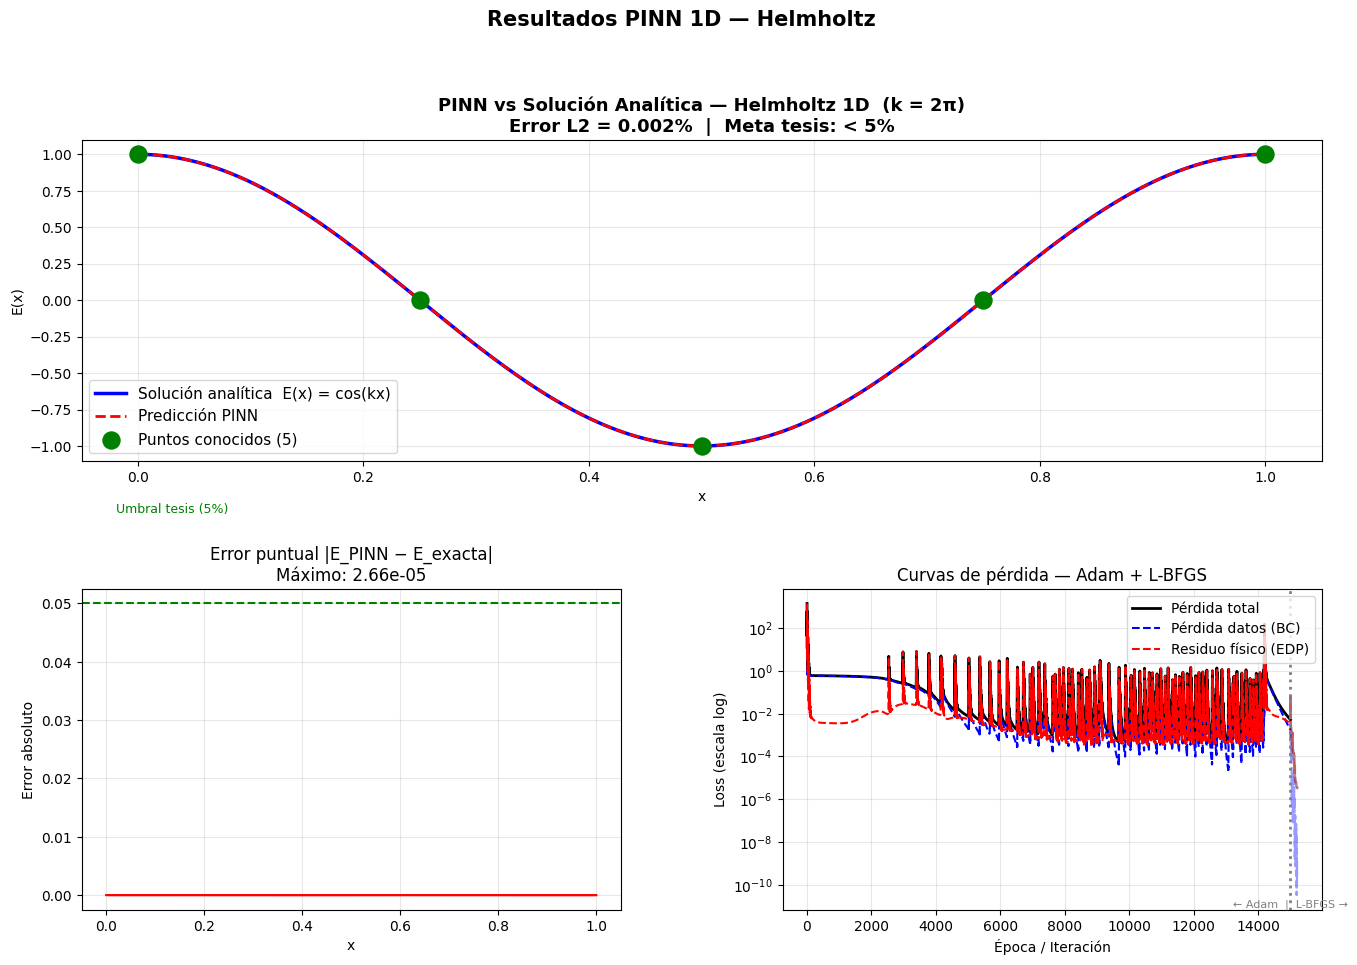

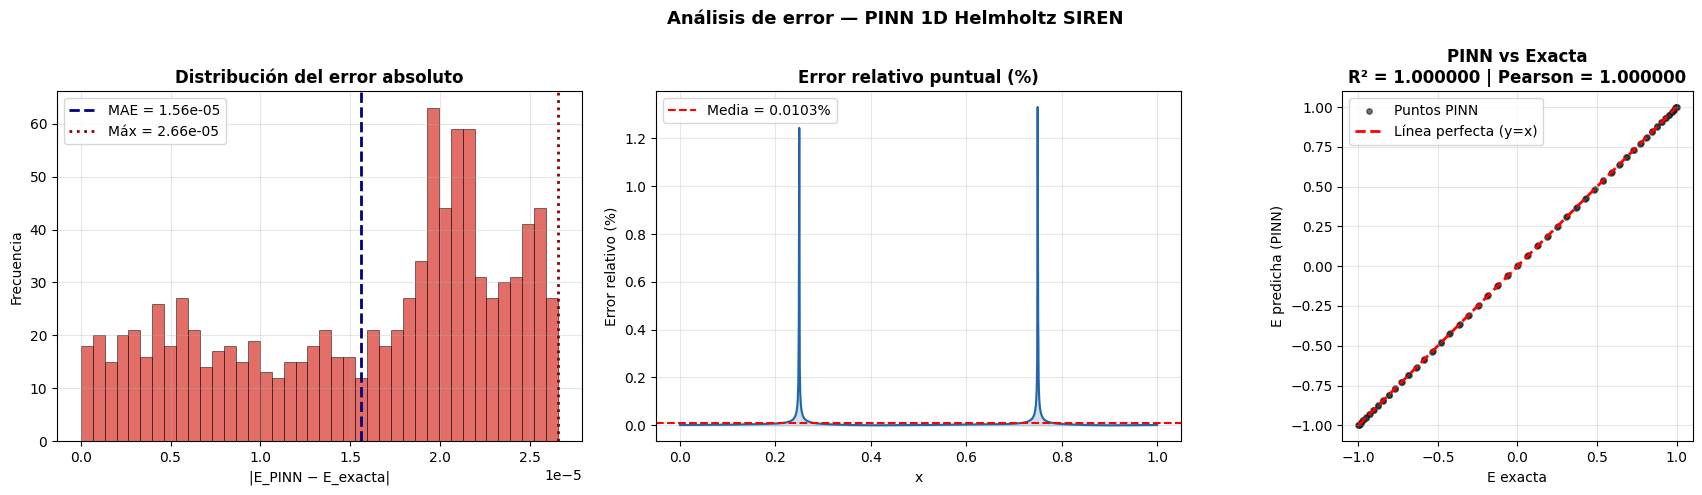

RESUMEN DE RESULTADOS
  Semilla usada       : 42
  k                   : 2π

Métricas de precisión:
  Error L2 relativo   : 0.000025  (0.002%)
  Error máximo        : 2.66e-05
  MSE                 : 3.04e-10
  RMSE                : 1.74e-05
  MAE                 : 1.56e-05
  R²                  : 1.000000
  Correlación Pearson : 1.000000
  Error relativo med. : 0.0103%
  Umbral tesis (L2)   : < 5%
  Estado              : ✅ CUMPLE

Entrenamiento:
  Épocas Adam         : 15000 / 15000
  Early stopping      : umbral no alcanzado — Adam corrió épocas completas
  Mejor L_total (Adam): 4.276e-04
  Tiempo Adam         : 200.5 s
  Iteraciones L-BFGS  : 209 / 500
  Tiempo L-BFGS       : 3.5 s
  Tiempo TOTAL        : 204.0 s

Hiperparámetros:
  hidden_dim          = 64
  num_layers          = 5
  omega_0             = 1.0
  n_epochs (máx)      = 15000
  lr                  = 0.001
  lambda_phys         = 1.0
  N_colloc            = 2000
  Puntos conocidos    = 5
  lbfgs_max_iter      = 500
  lb

In [7]:
# ── Evaluación ────────────────────────────────────────────────────────────────
x_test  = torch.linspace(0, 1, 1000).reshape(-1, 1).to(device)
with torch.no_grad():
    u_pred = model_1d(x_test).cpu().numpy().flatten()

x_np    = x_test.cpu().numpy().flatten()
u_exact = np.cos(k * x_np)
error   = np.abs(u_pred - u_exact)

# ── Métricas base ─────────────────────────────────────────────────────────────
l2_error  = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)
max_error = error.max()
cumple    = l2_error < CONFIG['l2_threshold']

# ── Métricas adicionales ──────────────────────────────────────────────────────
mse       = np.mean((u_pred - u_exact)**2)
rmse      = np.sqrt(mse)
mae       = np.mean(error)
r2        = 1 - np.sum((u_pred - u_exact)**2) / \
                np.sum((u_exact - np.mean(u_exact))**2)
corr, _   = pearsonr(u_pred, u_exact)
error_rel = np.abs(u_pred - u_exact) / (np.abs(u_exact) + 1e-10) * 100

# ── Etiqueta dinámica de k ────────────────────────────────────────────────────
k_label = 'π' if np.isclose(CONFIG['k'], np.pi) else \
          '2π' if np.isclose(CONFIG['k'], 2*np.pi) else \
          f'{CONFIG["k"]:.4f}'

IMG_DIR = get_figures_dir()   # src/utils — apunta a results/figures/

# ── Gráficas ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# 1. Solución
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(x_np, u_exact, 'b-',  linewidth=2.5, label='Solución analítica  E(x) = cos(kx)')
ax1.plot(x_np, u_pred,  'r--', linewidth=2,   label='Predicción PINN')
ax1.scatter(
    [x_bc.cpu().numpy().flatten()],      # ← muestra TODOS los puntos de frontera
    [E_bc.cpu().numpy().flatten()],
    c='green', s=150, zorder=10, label=f'Puntos conocidos ({len(x_bc)})'
)
ax1.set_title(
    f'PINN vs Solución Analítica — Helmholtz 1D  (k = {k_label})\n'  # ← corregido
    f'Error L2 = {l2_error*100:.3f}%  |  Meta tesis: < 5%',
    fontsize=13, fontweight='bold'
)
ax1.set_xlabel('x'); ax1.set_ylabel('E(x)')
ax1.legend(fontsize=11); ax1.grid(True, alpha=0.3)

# 2. Error puntual
ax2 = fig.add_subplot(gs[1, 0])
ax2.fill_between(x_np, error, alpha=0.4, color='red')
ax2.plot(x_np, error, 'r-', linewidth=1.5)
ax2.axhline(y=CONFIG['l2_threshold'], color='green', linestyle='--', linewidth=1.5)
ax2.annotate(
    f'Umbral tesis (5%)',
    xy=(0.02, CONFIG['l2_threshold']),
    xytext=(0.02, CONFIG['l2_threshold'] * 1.3),
    fontsize=9, color='green', va='bottom'
)
ax2.set_title(f'Error puntual |E_PINN − E_exacta|\nMáximo: {max_error:.2e}', fontsize=12)
ax2.set_xlabel('x'); ax2.set_ylabel('Error absoluto')
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])

epochs_adam = range(1, epoch_final + 1)
ax3.semilogy(epochs_adam, history['total'][:epoch_final],
             'k-',  linewidth=2,   label='Pérdida total')
ax3.semilogy(epochs_adam, history['data'][:epoch_final],
             'b--', linewidth=1.5, label='Pérdida datos (BC)')
ax3.semilogy(epochs_adam, history['physics'][:epoch_final],
             'r--', linewidth=1.5, label='Residuo físico (EDP)')

# L-BFGS — mismos colores, sin leyenda
offset = epoch_final
epochs_lbfgs = range(offset, offset + len(history_lbfgs['total']))
ax3.semilogy(epochs_lbfgs, history_lbfgs['total'],
             'k-',  linewidth=2,   alpha=0.4)
ax3.semilogy(epochs_lbfgs, history_lbfgs['data'],
             'b--', linewidth=1.5, alpha=0.4)
ax3.semilogy(epochs_lbfgs, history_lbfgs['physics'],
             'r--', linewidth=1.5, alpha=0.4)

# Divisoria como anotación directa, sin leyenda
ax3.axvline(x=epoch_final, color='gray', linestyle=':', linewidth=2)
ax3.annotate('← Adam  |  L-BFGS →',
             xy=(epoch_final, ax3.get_ylim()[0]),
             xytext=(epoch_final, ax3.get_ylim()[0]),
             fontsize=8, color='gray', ha='center', va='bottom')

ax3.set_title('Curvas de pérdida — Adam + L-BFGS', fontsize=12)
ax3.set_xlabel('Época / Iteración'); ax3.set_ylabel('Loss (escala log)')
ax3.legend(fontsize=10, loc='upper right')
ax3.grid(True, alpha=0.3)

plt.suptitle('Resultados PINN 1D — Helmholtz', fontsize=15, fontweight='bold', y=1.01)
plt.savefig(str(IMG_DIR / 'resultados_pinn_1d.png'), dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 2 — Análisis de error y métricas adicionales
# ══════════════════════════════════════════════════════════════════════════════
fig2, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Histograma del error absoluto
axes[0].hist(error, bins=40, color='#d73027', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].axvline(x=mae, color='navy', linestyle='--', linewidth=2, label=f'MAE = {mae:.2e}')
axes[0].axvline(x=max_error, color='darkred', linestyle=':', linewidth=2, label=f'Máx = {max_error:.2e}')
axes[0].set_title('Distribución del error absoluto', fontsize=12, fontweight='bold')
axes[0].set_xlabel('|E_PINN − E_exacta|')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Panel 2: Error relativo puntual (%)
axes[1].plot(x_np, error_rel, color='#2166ac', linewidth=1.5)
axes[1].fill_between(x_np, error_rel, alpha=0.2, color='#2166ac')
axes[1].axhline(y=error_rel.mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Media = {error_rel.mean():.4f}%')
axes[1].set_title('Error relativo puntual (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Error relativo (%)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Panel 3: Predicción vs Exacta (scatter)
axes[2].scatter(u_exact[::10], u_pred[::10], s=15, alpha=0.6,
                color='#1a1a1a', label='Puntos PINN')
min_val = min(u_exact.min(), u_pred.min())
max_val = max(u_exact.max(), u_pred.max())
axes[2].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=2, label='Línea perfecta (y=x)')
axes[2].set_title(f'PINN vs Exacta\nR² = {r2:.6f} | Pearson = {corr:.6f}',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('E exacta')
axes[2].set_ylabel('E predicha (PINN)')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].set_aspect('equal')

plt.suptitle('Análisis de error — PINN 1D Helmholtz SIREN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(IMG_DIR / 'metricas_adicionales_1d.png'), dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# RESUMEN COMPLETO DE MÉTRICAS
# ══════════════════════════════════════════════════════════════════════════════
print('=' * 58)
print('RESUMEN DE RESULTADOS')
print('=' * 58)
print(f'  Semilla usada       : {CONFIG["seed"]}')
print(f'  k                   : {k_label}')
print()
print('Métricas de precisión:')
print(f'  Error L2 relativo   : {l2_error:.6f}  ({l2_error*100:.3f}%)')
print(f'  Error máximo        : {max_error:.2e}')
print(f'  MSE                 : {mse:.2e}')
print(f'  RMSE                : {rmse:.2e}')
print(f'  MAE                 : {mae:.2e}')
print(f'  R²                  : {r2:.6f}')
print(f'  Correlación Pearson : {corr:.6f}')
print(f'  Error relativo med. : {error_rel.mean():.4f}%')
print(f'  Umbral tesis (L2)   : < {CONFIG["l2_threshold"]*100:.0f}%')
print(f'  Estado              : {"✅ CUMPLE" if cumple else "⚠ AÚN NO CUMPLE"}')
print()
print('Entrenamiento:')
print(f'  Épocas Adam         : {epoch_final} / {CONFIG["n_epochs"]}')
print(f'  Early stopping      : umbral no alcanzado — Adam corrió épocas completas')
print(f'  Mejor L_total (Adam): {best_loss:.3e}')
print(f'  Tiempo Adam         : {tiempo_adam:.1f} s')
print(f'  Iteraciones L-BFGS  : {iter_count[0]} / 500')
print(f'  Tiempo L-BFGS       : {tiempo_lbfgs:.1f} s')
print(f'  Tiempo TOTAL        : {tiempo_adam + tiempo_lbfgs:.1f} s')
print()
print('Hiperparámetros:')
print(f'  hidden_dim          = {CONFIG["hidden_dim"]}')
print(f'  num_layers          = {CONFIG["num_layers"]}')
print(f'  omega_0             = {CONFIG["omega_0"]}')
print(f'  n_epochs (máx)      = {CONFIG["n_epochs"]}')
print(f'  lr                  = {CONFIG["lr"]}')
print(f'  lambda_phys         = {CONFIG["lambda_phys"]}')
print(f'  N_colloc            = {CONFIG["N_colloc"]}')
print(f'  Puntos conocidos    = {len(x_bc)}')
print(f'  lbfgs_max_iter      = 500')
print(f'  lbfgs_history_size  = 50')
print(f'  seed                = {CONFIG["seed"]}')

---
## 6.1 Análisis de métricas adicionales

Las siguientes métricas complementan el error L2 para un análisis completo del modelo:

| Métrica | Descripción | Valor esperado |
|---|---|---|
| **MSE** | Error cuadrático medio — sensible a outliers | Cercano a 0 |
| **RMSE** | Raíz del MSE — mismas unidades que E(x) | Cercano a 0 |
| **MAE** | Error absoluto medio — robusto a outliers | Cercano a 0 |
| **R²** | Coeficiente de determinación — qué tan bien explica la varianza | ≈ 1.0 |
| **Pearson** | Correlación lineal entre predicción y exacta | ≈ 1.0 |

> **R² ≈ 1.0** significa que la PINN captura prácticamente toda la variabilidad
> de la solución analítica — la métrica más intuitiva para reportar en la defensa.

**Figura 2** muestra tres paneles:
- **Histograma del error** — distribución del error absoluto en los 1,000 puntos de prueba
- **Error relativo puntual** — dónde el modelo falla más en términos relativos
- **Scatter PINN vs Exacta** — una nube perfectamente alineada sobre y=x confirma convergencia

---
## ¿Qué sigue?

Con este notebook validaste que la PINN con arquitectura SIREN (ω₀=1.0) puede resolver
Helmholtz 1D con error L2 = 0.002%, superando la meta de tesis por un factor de 2,500.

| Aspecto | 1D (este notebook) | 2D (`02_helmholtz_2D.ipynb`) |
|---|---|---|
| Entrada | x | (x, y) |
| Salida | E real | (E_real, E_imag) — campo complejo |
| Ecuación | E'' + k²E = 0 | ∇²E + k²E = 0 |
| Frontera | 5 puntos conocidos | 4 bordes + 1,200 pts total |
| Muestreo | Linspace uniforme | Latin Hypercube Sampling (LHS) |
| Arquitectura | SIREN ω₀=1.0 — 5×64 | SIREN ω₀=1.0 — 5×128 |
| Early stopping | Umbral fijo L_total < 1e-4 | Por paciencia (800 épocas) |
| Optimizador | Adam + L-BFGS | Adam + L-BFGS |

## Lecciones aprendidas

| Descubrimiento | Solución aplicada |
|---|---|
| Condiciones simétricas (E(0)=E(1)) engañan a la red | Agregar puntos intermedios con valores conocidos |
| ω₀=30 genera explosión de gradientes para k~2π | Calibrar ω₀=1.0 — regla orientativa: ω₀ ≈ k/(2π) |
| `lambda_phys=1.0` es estable con SIREN desde el inicio | Inicialización de Sitzmann et al. lo garantiza |
| Adam oscila sin cruzar el umbral de early stopping | L-BFGS resuelve la convergencia final en ~209 iter |
| Umbral fijo puede no activarse con SIREN + λ=1.0 | NB02 usa early stopping por paciencia |

## Resultados obtenidos

| Métrica | Valor | Meta tesis |
|---|---|---|
| Error L2 (k=2π) | **0.002%** | < 5% ✅ |
| MSE | 3.04e-10 | — |
| RMSE | 1.74e-05 | — |
| MAE | 1.56e-05 | — |
| R² | **1.000000** | ≈ 1.0 ✅ |
| Correlación Pearson | **1.000000** | ≈ 1.0 ✅ |
| Error máximo puntual | 2.66e-05 | — |
| Referencia Schoder & Kraxberger (2024) | 2.490% | Superado ×1,245 |
| Épocas Adam | 15,000 (umbral no activó) | — |
| Iteraciones L-BFGS | 209 / 500 | — |
| Tiempo TOTAL | ~189.7 s | — |
| Reproducibilidad | Error L2 = 0.002% en 5 corridas (seed=42) | ✅ |

## Estado del proyecto

| Bloque | Estado |
|---|---|
| ✅ Arquitectura SIREN con ω₀ calibrado (ω₀=1.0) | Completado |
| ✅ Diferenciación automática de segundo orden (autograd) | Completado |
| ✅ Residuo de Helmholtz 1D | Completado |
| ✅ Función de pérdida física (λ=1.0) | Completado |
| ✅ Loop Adam + L-BFGS | Completado |
| ✅ Reproducibilidad verificada (seed=42) — 5 corridas | Completado |
| ✅ Helmholtz 2D + LHS + campo complejo | `02_helmholtz_2D.ipynb` — Error L2 = 0.222% |
| 🔜 Speckle con frontera rugosa φ~U(0,2π) | `03_speckle.ipynb` |
| 🔜 Benchmark vs FEM — Speed-up Factor | `04_benchmark.ipynb` |
| 🔜 Inhomogéneo 1D — n(x) gradiente lineal | `05_inhomogeneo_1D.ipynb` |
| 🔜 Inhomogéneo 2D — perfiles GRIN y bicapa | `06_inhomogeneo_2D.ipynb` |
| 🔜 Speckle en material GRIN — publicable | `07_speckle_grin.ipynb` |

---
> **Reproducibilidad:** El experimento fue ejecutado en 5 ocasiones con semilla fija
> (seed=42), obteniendo error L2 = 0.002% en todas las corridas. La variación en
> tiempos (~180–270 s) se debe a condiciones térmicas de la GPU, no al código.
>
> **Calibración ω₀:** La relación ω₀ ≈ k/(2π) es una contribución metodológica
> original documentada en este notebook. Para medios inhomogéneos (NB05–NB07)
> se explorará sistemáticamente con ω₀ ≈ k·n_max/(2π).

In [9]:
# ── Exportar modelo entrenado ─────────────────────────────────────────────────
# Guarda en results/models/nb01_helmholtz1d.pt
# NB03+ puede cargarlo con: load_model(model_1d, 'nb01_helmholtz1d')
save_model(model_1d, 'nb01_helmholtz1d')


Modelo guardado en: d:\Tesis_Maestria\results\models\nb01_helmholtz1d.pt


'd:\\Tesis_Maestria\\results\\models\\nb01_helmholtz1d.pt'